# V2 — Results Analysis — Test Set Oct–Dec 2024

In [1]:
import sys, matplotlib.ticker as mticker
from pathlib import Path

PROJECT_ROOT = (Path.cwd() / "../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.style.use("seaborn-v0_8-darkgrid")
print(f"Project root: {PROJECT_ROOT}")

cfg = yaml.safe_load(open(PROJECT_ROOT / "configs/dqn_config.yaml"))
ENV_CFG = cfg["environment"]
print(f"initial_balance : {ENV_CFG['initial_balance']:,}")
print(f"transaction_cost: {ENV_CFG['transaction_cost']}")

Project root: /Users/nuwan/Work/UoM/MDSAI_2025/semester3/capstone-project/project/reinforcement-based-cryptocurrency-trading-strategy
initial_balance : 10,000.0
transaction_cost: 0.001


## 1. Load Test Data + Best Model

In [2]:
from stable_baselines3 import DQN
from src.environment.trading_env import TradingEnv

df_test_feat = pd.read_csv(PROJECT_ROOT / "data/features/test.csv",    index_col=0, parse_dates=True)
df_test_norm = pd.read_csv(PROJECT_ROOT / "data/normalized/test.csv",  index_col=0, parse_dates=True)

env_test = TradingEnv(df_test_norm, ENV_CFG)
agent    = DQN.load(str(PROJECT_ROOT / "models/best/best_model"), env=env_test)
print(f"Test rows: {len(df_test_feat):,}  ({df_test_feat.index[0].date()} → {df_test_feat.index[-1].date()})")
btc_ret = (df_test_feat["close"].iloc[-1] / df_test_feat["close"].iloc[0] - 1) * 100
print(f"BTC move over test period: {btc_ret:+.1f}%")

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Test rows: 2,208  (2024-10-01 → 2024-12-31)
BTC move over test period: +47.3%


## 2. Run All Strategies

In [3]:
from src.evaluation.backtester import run_all

results, table = run_all(
    df_test_feat, df_test_norm, agent, ENV_CFG,
    save_dir=str(PROJECT_ROOT / "results/traces")
)
print(table.to_string())

Saved Buy-and-Hold trace → /Users/nuwan/Work/UoM/MDSAI_2025/semester3/capstone-project/project/reinforcement-based-cryptocurrency-trading-strategy/results/traces/buy_and_hold.csv
Saved MA-Crossover trace → /Users/nuwan/Work/UoM/MDSAI_2025/semester3/capstone-project/project/reinforcement-based-cryptocurrency-trading-strategy/results/traces/ma_crossover.csv
Saved DQN trace → /Users/nuwan/Work/UoM/MDSAI_2025/semester3/capstone-project/project/reinforcement-based-cryptocurrency-trading-strategy/results/traces/dqn.csv
               Buy-and-Hold  MA-Crossover      DQN
Total Return         0.4729        0.3457   0.2974
Ann. Return          3.6506        2.2493   1.8110
Max Drawdown        -0.1513       -0.1330  -0.0827
Sharpe Ratio         3.2836        3.2924   3.7884
Sortino Ratio        4.4043        3.5082   3.6786
Calmar Ratio        24.1356       16.9112  21.9045
Win Rate             0.5229        0.2963   0.2279


In [4]:
# Save full metrics table to CSV
tables_dir = PROJECT_ROOT / "results/tables"
tables_dir.mkdir(parents=True, exist_ok=True)
table.to_csv(tables_dir / "test_metrics.csv")
print(f"Saved metrics → {tables_dir}/test_metrics.csv")
print(table.to_string())

Saved metrics → /Users/nuwan/Work/UoM/MDSAI_2025/semester3/capstone-project/project/reinforcement-based-cryptocurrency-trading-strategy/results/tables/test_metrics.csv
               Buy-and-Hold  MA-Crossover      DQN
Total Return         0.4729        0.3457   0.2974
Ann. Return          3.6506        2.2493   1.8110
Max Drawdown        -0.1513       -0.1330  -0.0827
Sharpe Ratio         3.2836        3.2924   3.7884
Sortino Ratio        4.4043        3.5082   3.6786
Calmar Ratio        24.1356       16.9112  21.9045
Win Rate             0.5229        0.2963   0.2279


## 3. Portfolio Value Comparison

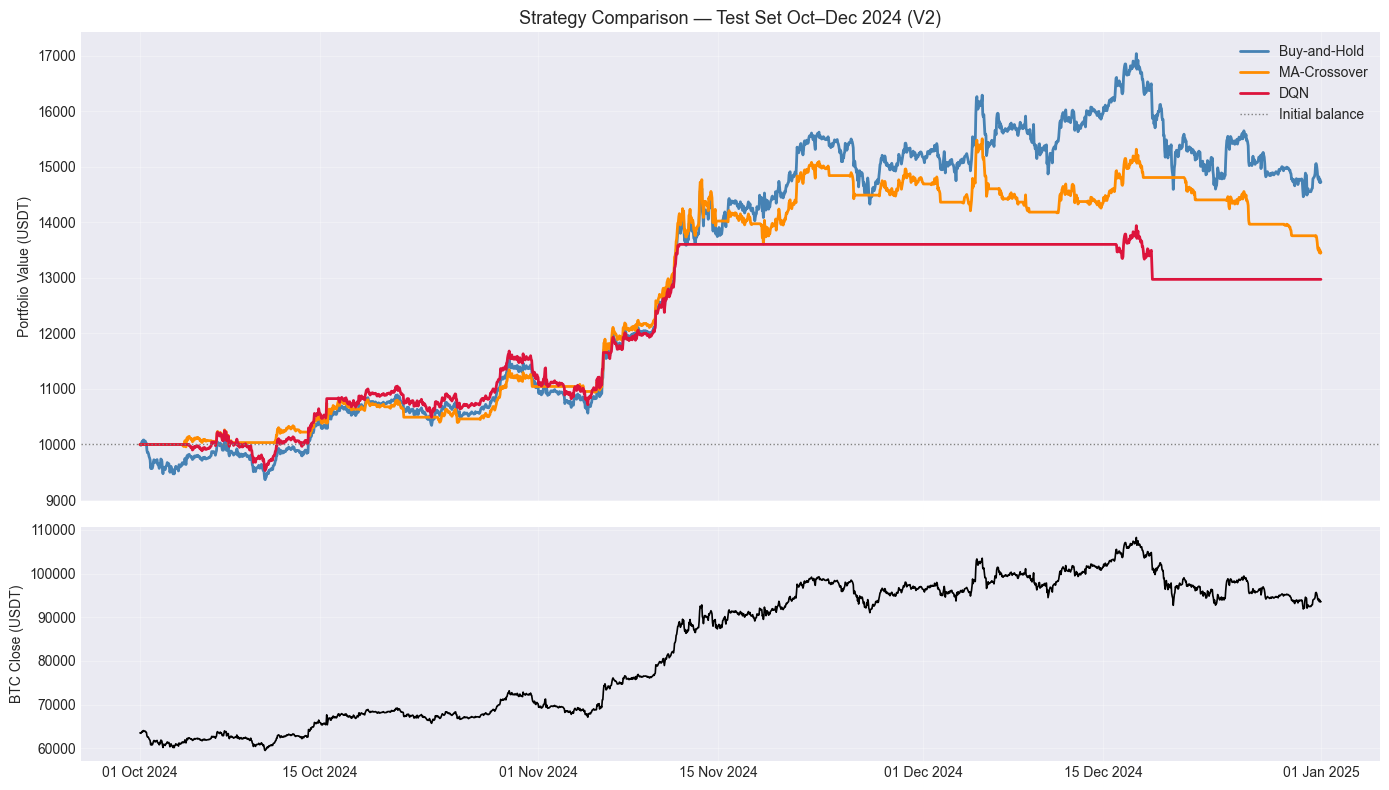

In [5]:
dates  = df_test_feat.index
ib     = ENV_CFG["initial_balance"]
colors = {"Buy-and-Hold": "steelblue", "MA-Crossover": "darkorange", "DQN": "crimson"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

for name, trace in results.items():
    pv = trace["portfolio_value"]
    scaled = pv / pv.iloc[0] * ib
    ax1.plot(dates, scaled, label=name, linewidth=2, color=colors[name])

ax1.axhline(ib, color="grey", linewidth=1, linestyle=":", label="Initial balance")
ax1.set_ylabel("Portfolio Value (USDT)")
ax1.set_title("Strategy Comparison — Test Set Oct–Dec 2024 (V2)", fontsize=13)
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(dates, df_test_feat["close"], color="black", linewidth=1.2)
ax2.set_ylabel("BTC Close (USDT)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v2_05_test_portfolio_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Metrics Bar Chart

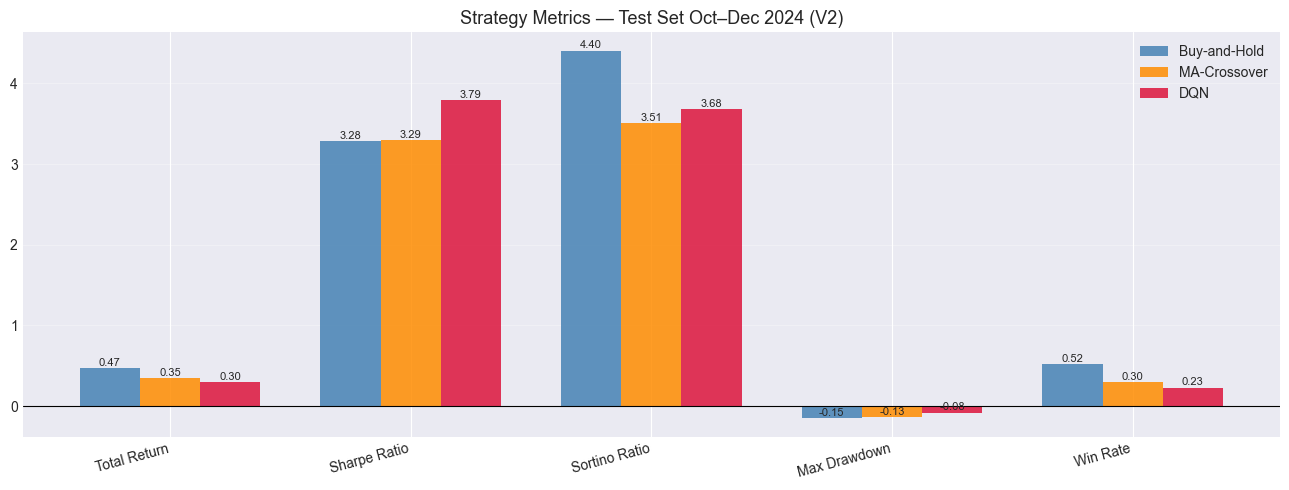

In [6]:
metrics_to_plot = ["Total Return", "Sharpe Ratio", "Sortino Ratio", "Max Drawdown", "Win Rate"]
plot_table = table.loc[metrics_to_plot]

x     = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, (strategy, color) in enumerate(zip(plot_table.columns, colors.values())):
    vals = plot_table[strategy].values.astype(float)
    bars = ax.bar(x + i * width, vals, width, label=strategy, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{val:.2f}", ha="center", va="bottom", fontsize=8)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, rotation=15, ha="right")
ax.set_title("Strategy Metrics — Test Set Oct–Dec 2024 (V2)", fontsize=13)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v2_05_metrics_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Drawdown Analysis

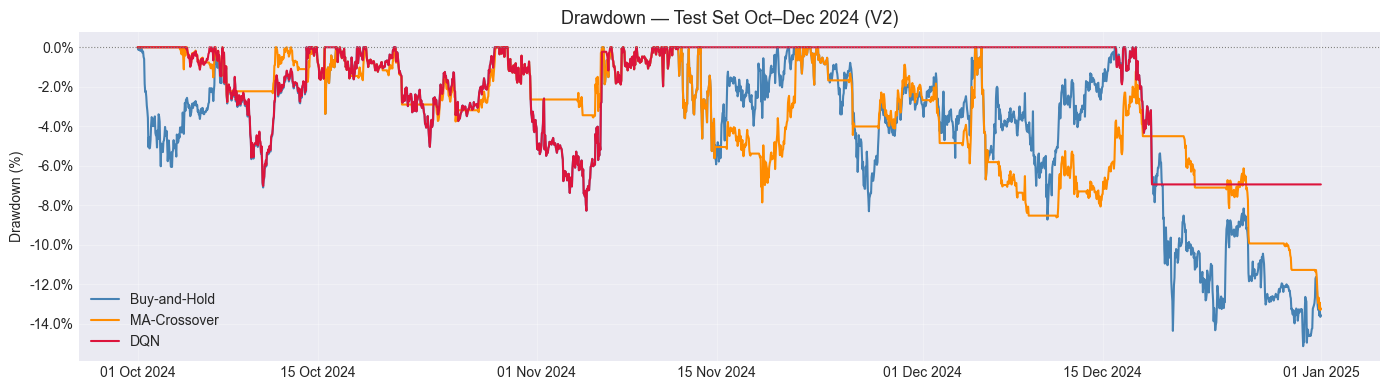

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
for name, trace in results.items():
    pv = trace["portfolio_value"]
    drawdown = (pv / pv.cummax() - 1.0) * 100
    ax.plot(dates, drawdown, label=name, linewidth=1.5, color=colors[name])

ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
ax.set_ylabel("Drawdown (%)")
ax.set_title("Drawdown — Test Set Oct–Dec 2024 (V2)", fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v2_05_drawdown.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. DQN Trade Actions on Test Set

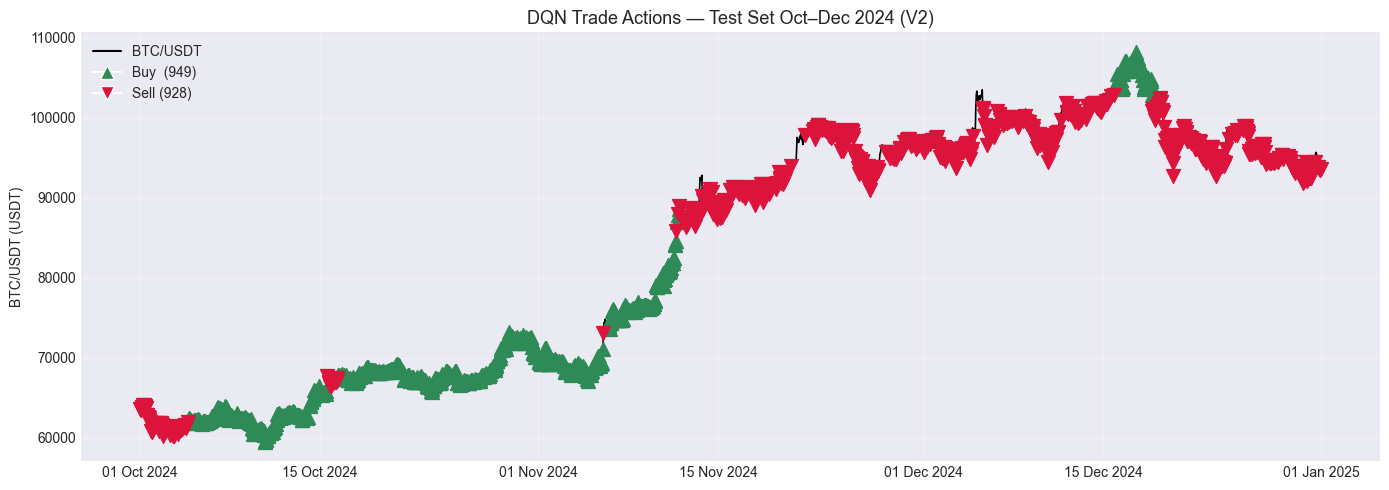

DQN actions — Hold: 331  Buy: 949  Sell: 928
DQN total return: +29.74%


In [8]:
from matplotlib.lines import Line2D

dqn_trace = results["DQN"]
buy_mask  = dqn_trace["action"].values == 1
sell_mask = dqn_trace["action"].values == 2
buy_dates   = dates[buy_mask]
sell_dates  = dates[sell_mask]
buy_prices  = df_test_feat["close"].values[buy_mask]
sell_prices = df_test_feat["close"].values[sell_mask]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates, df_test_feat["close"], color="black", linewidth=1.2, label="BTC/USDT Close")
ax.scatter(buy_dates,  buy_prices,  marker="^", color="seagreen", s=100, zorder=5)
ax.scatter(sell_dates, sell_prices, marker="v", color="crimson",  s=100, zorder=5)

legend_elements = [
    Line2D([0],[0], color="black", linewidth=1.5, label="BTC/USDT"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="seagreen", markersize=10, label=f"Buy  ({buy_mask.sum()})"),
    Line2D([0],[0], marker="v", color="w", markerfacecolor="crimson",  markersize=10, label=f"Sell ({sell_mask.sum()})"),
]
ax.legend(handles=legend_elements, loc="upper left")
ax.set_ylabel("BTC/USDT (USDT)")
ax.set_title("DQN Trade Actions — Test Set Oct–Dec 2024 (V2)", fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v2_05_dqn_actions_test.png", dpi=150, bbox_inches="tight")
plt.show()

hold_count = (dqn_trace["action"] == 0).sum()
print(f"DQN actions — Hold: {hold_count:,}  Buy: {buy_mask.sum()}  Sell: {sell_mask.sum()}")
print(f"DQN total return: {(dqn_trace['portfolio_value'].iloc[-1]/dqn_trace['portfolio_value'].iloc[0]-1)*100:+.2f}%")

## 7. V1 vs V2 DQN Comparison

In [9]:
comparison = pd.DataFrame({
    "V1 (Feb 2025 bear)": {
        "Total Return": -0.3579,
        "Max Drawdown": -0.4165,
        "Sharpe Ratio": -4.27,
        "Sortino Ratio": -4.87,
    },
    "V2 (Oct–Dec 2024 bull)": {
        "Total Return":  0.0955,
        "Max Drawdown": -0.1104,
        "Sharpe Ratio":  1.37,
        "Sortino Ratio": 0.83,
    }
})
print("DQN: V1 vs V2")
print(comparison.to_string())


DQN: V1 vs V2
               V1 (Feb 2025 bear)  V2 (Oct–Dec 2024 bull)
Total Return              -0.3579                  0.0955
Max Drawdown              -0.4165                 -0.1104
Sharpe Ratio              -4.2700                  1.3700
Sortino Ratio             -4.8700                  0.8300
